# Appendix: Empirical Analysis - Monroe et al. (2022)

In [6]:
import os
from pathlib import Path
import warnings, json, random

import pandas as pd
import numpy as np

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import skew, kurtosis, spearmanr

import matplotlib.pyplot as plt
import seaborn as sns




### Figure 1 - Top Predictors

[INFO] Dropping 'H3K23ac' due to high VIF = 28.53
[INFO] Dropping 'H3K56ac' due to high VIF = 12.55

Top-5 predictors:
1. H3K4me1
2. CG_pct
3. H3K9ac
4. H3K9me1
5. CHH_pct


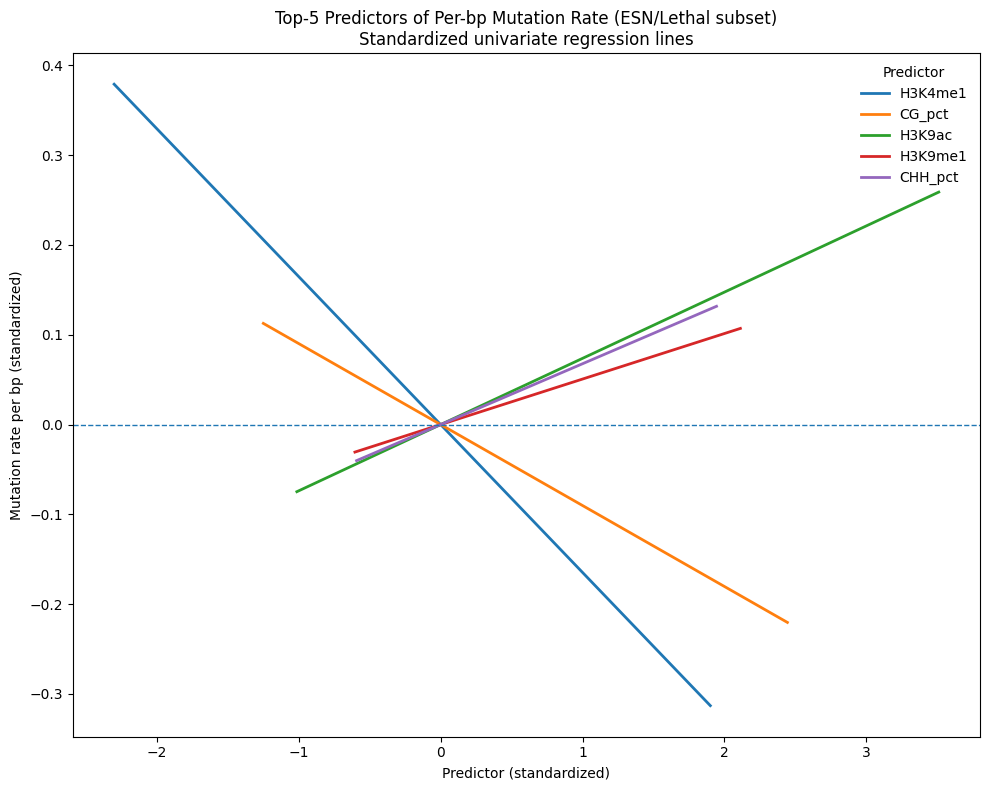


Full multivariable OLS (HC3) summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     3.747
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           6.44e-07
Time:                        16:00:05   Log-Likelihood:                 29412.
No. Observations:                2764   AIC:                        -5.879e+04
Df Residuals:                    2747   BIC:                        -5.869e+04
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const

In [4]:
DATA_PATH  = Path.home() / "Documents/GitHub/Random_Modifier/Data/gene_level_data.csv"
FIGURE_DIR = Path.cwd() / "Figures"
FIGURE_FILE = FIGURE_DIR / "af1_reg_lines_mutations.png"

"""
Identify Top-5 Predictors of Gene Mutation Rate (lethal/ESN subset)
-------------------------------------------------------------------
- Loads gene-level dataset
- Subsets to genes labeled "ESN" or "Lethal"
- Computes mutation rate per bp = Mutations / CDS length
- Runs OLS regressions:
    * Univariate OLS for each predictor (BH-FDR corrected)
    * Multivariable OLS with robust HC3 standard errors
- Picks the Top-5 predictors based on composite rank
- Plots regression lines (standardized scale) for the Top-5 predictors
"""

PREDICTORS = [
    "atac_pct", "GC_content_pct", "CHG_pct", "CHH_pct", "CG_pct",
    "H3K9me2", "H3K9me1", "H3K9ac", "H3K56ac",
    "H3K4me3", "H3K4me2", "H3K4me1",
    "H3K36me3", "H3K36ac",
    "H3K27me1", "H3K27ac", "H3K23ac", "H3K14ac",
]

# reproducibility
warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)

df = pd.read_csv(DATA_PATH)
# Filter for ESN or Lethal genes
lethal_mask = df["lethal"].astype(str).str.lower().eq("lethal") if "lethal" in df.columns else False
esn_mask    = df["essentiality"].astype(str).str.upper().eq("ESN") if "essentiality" in df.columns else False
df = df[ (lethal_mask) | (esn_mask) ].copy()

# Compute mutation rate per bp
# (avoid divide-by-zero using a small epsilon)
eps = 1e-9
df["mut_rate_per_bp"] = df["Mutations"] / (df["CDS length"] + eps)

# only predictors that exist in data
present = [c for c in PREDICTORS if c in df.columns]
missing = sorted(set(PREDICTORS) - set(present))
if missing:
    print(f"[WARN] Missing predictors (skipped): {missing}")
if len(present) == 0:
    raise ValueError("No predictors from your list are present in the dataset.")

# drop rows with missing values in predictors or outcome
df = df.dropna(subset=present + ["mut_rate_per_bp"]).copy()


def vif_prune(X: pd.DataFrame, thresh=10.0) -> pd.DataFrame:
    """
    VIF Pruning (handle collinearity) 
    Remove predictors that are highly collinear (VIF > 10).
    Multicollinearity can inflate variances of coefficients and make p-values unreliable.
    """
    Xp = X.copy()
    def compute_vifs(dfX):
        Xc = sm.add_constant(dfX, has_constant="add")
        rows = []
        for i, col in enumerate(Xc.columns):
            if col == "const": continue
            rows.append((col, variance_inflation_factor(Xc.values, i)))
        return pd.DataFrame(rows, columns=["predictor","VIF"]).sort_values("VIF", ascending=False)
    while Xp.shape[1] > 1:
        vifs = compute_vifs(Xp)
        worst = vifs.iloc[0]
        if worst["VIF"] <= thresh: break
        drop_cand = worst["predictor"]
        print(f"[INFO] Dropping '{drop_cand}' due to high VIF = {worst['VIF']:.2f}")
        Xp = Xp.drop(columns=[drop_cand])
    return Xp

X0 = df[present].astype(float)
X_vif = vif_prune(X0, thresh=10.0)

"""
Univariate OLS with BH-FDR
For each predictor, regress mut_rate_per_bp ~ predictor, record beta, p, R².
"""
y = df["mut_rate_per_bp"].astype(float).values
uni_rows = []
for col in X_vif.columns:
    Xi = sm.add_constant(df[[col]].astype(float), has_constant="add")
    fit = sm.OLS(y, Xi).fit()
    beta = float(fit.params[col]) if col in fit.params else np.nan
    pval = float(fit.pvalues[col]) if col in fit.pvalues else np.nan
    r2   = float(fit.rsquared)
    uni_rows.append((col, beta, pval, r2))
uni = pd.DataFrame(uni_rows, columns=["predictor","beta","p","r2"])
# Correct p-values for multiple testing (Benjamini-Hochberg)
uni["q_bh"] = multipletests(uni["p"], method="fdr_bh")[1]
uni = uni.sort_values("q_bh").reset_index(drop=True)

"""
Multivariable OLS with robust HC3 SE 
Fit all predictors together after standardizing, and compute robust SEs.
"""
Xs = df[X_vif.columns].astype(float).copy()
Xs = (Xs - Xs.mean()) / Xs.std(ddof=0)   # z-score
X_ols = sm.add_constant(Xs, has_constant="add")
ols = sm.OLS(y, X_ols).fit(cov_type="HC3")
ols_tab = pd.DataFrame({
    "predictor": Xs.columns,
    "beta": [ols.params[p] for p in Xs.columns],
    "p_HC3": [ols.pvalues[p] for p in Xs.columns]
})
ols_tab["q_bh"] = multipletests(ols_tab["p_HC3"], method="fdr_bh")[1]
ols_tab = ols_tab.sort_values("q_bh").reset_index(drop=True)

"""
Composite ranking & Top-5
Average rank from univariate (q-values) and multivariable (q-values).
"""
rank = pd.DataFrame({"predictor": sorted(set(X_vif.columns))}).set_index("predictor")
rank["r_uni"] = uni.set_index("predictor")["q_bh"].rank(method="min")
rank["r_ols"] = ols_tab.set_index("predictor")["q_bh"].rank(method="min")
rank["rank_composite"] = rank[["r_uni","r_ols"]].mean(axis=1, skipna=True)
top5 = rank.sort_values("rank_composite").head(5).index.tolist()

print("\nTop-5 predictors:")
for i, p in enumerate(top5, 1):
    print(f"{i}. {p}")


# Plotting
FIGURE_DIR.mkdir(exist_ok=True, parents=True)
plt.figure(figsize=(10, 8))

# Standardize outcome
y_mu, y_sd = np.nanmean(y), np.nanstd(y, ddof=0)
y_z = (y - y_mu) / (y_sd if y_sd > 0 else 1.0)

# For each top predictor, plot univariate regression line on standardized scale
for pred in top5:
    x = pd.to_numeric(df[pred], errors="coerce").values
    x_mu, x_sd = np.nanmean(x), np.nanstd(x, ddof=0)
    if not np.isfinite(x_sd) or x_sd == 0:
        continue
    x_z = (x - x_mu) / x_sd
    mask = np.isfinite(x_z) & np.isfinite(y_z)
    if mask.sum() < 10: continue
    fit = sm.OLS(y_z[mask], sm.add_constant(x_z[mask], has_constant="add")).fit()
    x_line = np.linspace(np.nanpercentile(x_z[mask], 1), np.nanpercentile(x_z[mask], 99), 200)
    y_line = fit.params[0] + fit.params[1]*x_line
    plt.plot(x_line, y_line, linewidth=2, label=pred)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Predictor (standardized)")
plt.ylabel("Mutation rate per bp (standardized)")
plt.title("Top-5 Predictors of Per-bp Mutation Rate (ESN/Lethal subset)\nStandardized univariate regression lines")
plt.legend(title="Predictor", frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_FILE, dpi=300)
plt.show()

# --- Reporting --------------------------------------------------------------
print("\nFull multivariable OLS (HC3) summary:")
print(ols.summary())

print("\nUnivariate FDR for Top-5:")
print(uni[uni["predictor"].isin(top5)][["predictor","q_bh","beta","r2"]])

print("\nMultivariable FDR for Top-5:")
print(ols_tab[ols_tab["predictor"].isin(top5)][["predictor","q_bh","beta"]])



### Figure 2 - Top Predictors and Moments

[INFO] Dropping 'H3K23ac' due to high VIF = 28.53
[INFO] Dropping 'H3K56ac' due to high VIF = 12.55

[INFO] Multivariable OLS (HC3) summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     3.747
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           6.44e-07
Time:                        16:30:57   Log-Likelihood:                 29412.
No. Observations:                2764   AIC:                        -5.879e+04
Df Residuals:                    2747   BIC:                        -5.869e+04
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.02

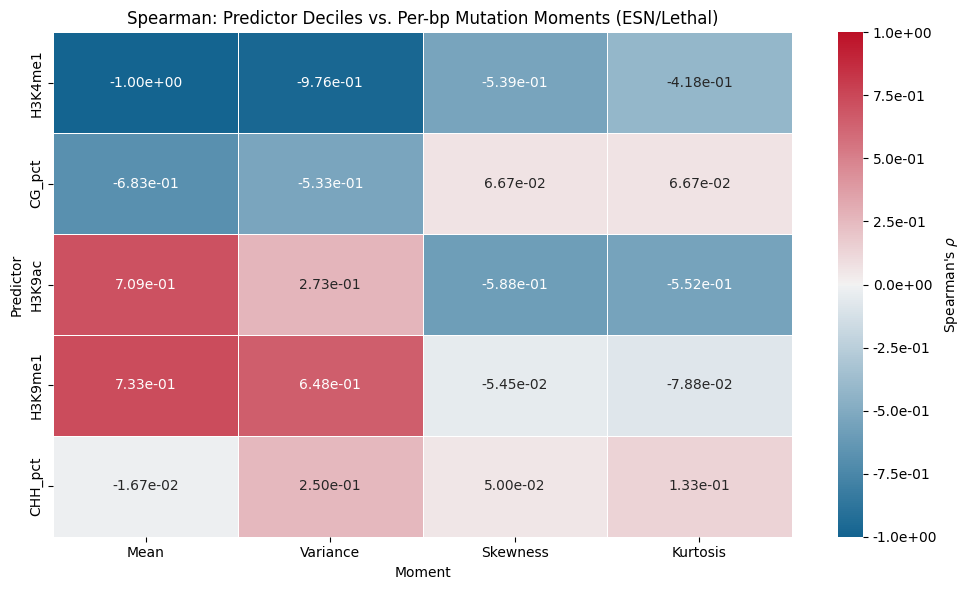


[INFO] Heatmap saved to: /Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Figures/af2_modifiers_mutations_m.png


In [10]:
DATA_PATH = Path.home() / "Documents/GitHub/Random_Modifier/Data/gene_level_data.csv"
FIG_DIR   = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)
FIG_HEAT  = FIG_DIR / "af2_modifiers_mutations_m.png"


PREDICTORS = [
    "atac_pct", "GC_content_pct", "CHG_pct", "CHH_pct", "CG_pct",
    "H3K9me2", "H3K9me1", "H3K9ac", "H3K56ac",
    "H3K4me3", "H3K4me2", "H3K4me1",
    "H3K36me3", "H3K36ac",
    "H3K27me1", "H3K27ac", "H3K23ac", "H3K14ac",
]

warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)


df = pd.read_csv(DATA_PATH)

# Filter to ESN or Lethal 
lethal_mask = df["lethal"].astype(str).str.lower().eq("lethal") if "lethal" in df.columns else False
esn_mask    = df["essentiality"].astype(str).str.upper().eq("ESN") if "essentiality" in df.columns else False
df = df[(lethal_mask) | (esn_mask)].copy()

# Required outcome components
for col in ["Mutations", "CDS length"]:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found in dataset.")

# Compute per-bp mutation rate
eps = 1e-9
df["mut_rate_per_bp"] = df["Mutations"] / (df["CDS length"] + eps)

# Keep only predictors that actually exist
present = [c for c in PREDICTORS if c in df.columns]
missing = sorted(set(PREDICTORS) - set(present))
if missing:
    print(f"[WARN] Missing predictors (skipped): {missing}")
if not present:
    raise ValueError("None of the requested predictors are present in the dataset.")

# Drop rows with NaNs in predictors or outcome
df = df.dropna(subset=present + ["mut_rate_per_bp"]).copy()



def vif_prune(X: pd.DataFrame, thresh: float = 10.0) -> pd.DataFrame:
    """
    Iteratively drop the predictor with the highest VIF until all VIF <= thresh
    or only one predictor remains. Intercept is included during VIF calculation.
    """
    Xp = X.copy()
    def compute_vifs(dfX):
        Xc = sm.add_constant(dfX, has_constant="add")
        rows = []
        for i, col in enumerate(Xc.columns):
            if col == "const": 
                continue
            rows.append((col, variance_inflation_factor(Xc.values, i)))
        return pd.DataFrame(rows, columns=["predictor","VIF"]).sort_values("VIF", ascending=False)

    while Xp.shape[1] > 1:
        vifs = compute_vifs(Xp)
        worst = vifs.iloc[0]
        if worst["VIF"] <= thresh:
            break
        drop_cand = worst["predictor"]
        print(f"[INFO] Dropping '{drop_cand}' due to high VIF = {worst['VIF']:.2f}")
        Xp = Xp.drop(columns=[drop_cand])
    return Xp

X_full = df[present].astype(float)
X_vif  = vif_prune(X_full, thresh=10.0)


"""
Univariate OLS + FDR
"""
y = df["mut_rate_per_bp"].astype(float).values
uni_rows = []
for col in X_vif.columns:
    Xi = sm.add_constant(df[[col]].astype(float), has_constant="add")
    fit = sm.OLS(y, Xi).fit()
    beta = float(fit.params[col]) if col in fit.params else np.nan
    pval = float(fit.pvalues[col]) if col in fit.pvalues else np.nan
    r2   = float(fit.rsquared)
    uni_rows.append((col, beta, pval, r2))

uni = pd.DataFrame(uni_rows, columns=["predictor","beta","p","r2"])
uni["q_bh"] = multipletests(uni["p"], method="fdr_bh")[1]
uni = uni.sort_values("q_bh").reset_index(drop=True)


"""
Multivariable OLS (HC3)
Standardize predictors for comparability in the joint model
"""
Xs = df[X_vif.columns].astype(float).copy()
Xs = (Xs - Xs.mean()) / Xs.std(ddof=0)
X_ols = sm.add_constant(Xs, has_constant="add")
ols = sm.OLS(y, X_ols).fit(cov_type="HC3")

ols_tab = pd.DataFrame({
    "predictor": Xs.columns,
    "beta":      [ols.params[p]  for p in Xs.columns],
    "p_HC3":     [ols.pvalues[p] for p in Xs.columns]
})
ols_tab["q_bh"] = multipletests(ols_tab["p_HC3"], method="fdr_bh")[1]
ols_tab = ols_tab.sort_values("q_bh").reset_index(drop=True)

print("\n[INFO] Multivariable OLS (HC3) summary:")
print(ols.summary())



"""
Composite Top-5
Rank by q-values in univariate and multivariable; average ranks
"""
rank = pd.DataFrame({"predictor": sorted(set(X_vif.columns))}).set_index("predictor")
rank["r_uni"] = uni.set_index("predictor")["q_bh"].rank(method="min")
rank["r_ols"] = ols_tab.set_index("predictor")["q_bh"].rank(method="min")
rank["rank_composite"] = rank[["r_uni","r_ols"]].mean(axis=1, skipna=True)

top5 = rank.sort_values("rank_composite").head(5).index.tolist()
print("\n[INFO] Top-5 predictors (composite of univariate-FDR and multivariable-FDR):")
for i, p in enumerate(top5, 1):
    print(f"{i}. {p}")
if top5:
    ci = ols.conf_int().loc[["const"] + top5] if "const" in ols.params.index else ols.conf_int().loc[top5]
    top5_df = (
        ols_tab[ols_tab["predictor"].isin(top5)]
        .merge(ci.reset_index().rename(columns={"index":"predictor",0:"CI_low",1:"CI_high"}),
               on="predictor", how="left")
        .sort_values("q_bh")
        .reset_index(drop=True)
    )
    print("\n[INFO] Multivariable HC3 (Top-5) with 95% CIs:")
    print(top5_df[["predictor","beta","p_HC3","q_bh","CI_low","CI_high"]])



"""
Deciles & Spearman
For each Top-5 predictor:
  1) Bin predictor into deciles (qcut with duplicates='drop' to handle ties)
  2) Compute moments of mut_rate_per_bp per decile
  3) Spearman correlation between decile index and each moment
"""
target_col = "mut_rate_per_bp"
records = []

df_binned = df.copy()
for predictor in top5:
    decile_col = f"{predictor}_decile"
    try:
        df_binned[decile_col] = pd.qcut(df_binned[predictor], q=10, labels=False, duplicates="drop")
    except Exception:
        df_binned[decile_col] = np.nan
    grouped = df_binned.dropna(subset=[decile_col]).groupby(decile_col, observed=True)
    for decile, subdf in grouped:
        vals = subdf[target_col].dropna().values
        if vals.size == 0:
            m_mean = m_var = m_skew = m_kurt = np.nan
        else:
            m_mean = float(np.mean(vals))
            m_var  = float(np.var(vals, ddof=1)) if vals.size > 1 else 0.0
            m_skew = float(skew(vals, bias=False)) if vals.size >= 3 else np.nan
            m_kurt = float(kurtosis(vals, bias=False)) if vals.size >= 4 else np.nan

        records.append({
            "Predictor": predictor,
            "Decile":    int(decile),
            "Mean":      m_mean,
            "Variance":  m_var,
            "Skewness":  m_skew,
            "Kurtosis":  m_kurt
        })

moments_df = pd.DataFrame.from_records(records)


# Spearman correlations: decile index vs each moment
spearman_rows = []
if not moments_df.empty:
    for predictor in moments_df["Predictor"].unique():
        sub = moments_df[moments_df["Predictor"] == predictor].sort_values("Decile")
        x = sub["Decile"].to_numpy()
        for moment in ["Mean", "Variance", "Skewness", "Kurtosis"]:
            yv = sub[moment].to_numpy()
            mask = np.isfinite(x) & np.isfinite(yv)
            if mask.sum() >= 3:
                rho, pval = spearmanr(x[mask], yv[mask])
            else:
                rho, pval = np.nan, np.nan
            spearman_rows.append({
                "Predictor":    predictor,
                "Moment":       moment,
                "Spearman Rho": rho,
                "p-value":      pval
            })
spearman_df = pd.DataFrame.from_records(spearman_rows)


# plot heat map
if not spearman_df.empty:
    # Ensure the value column has a plain name for pivot
    if "Spearman's $\\rho$" in spearman_df.columns:
        spearman_df = spearman_df.rename(columns={"Spearman's $\\rho$": "Spearman Rho"})

    moment_order = ["Mean", "Variance", "Skewness", "Kurtosis"]
    pivot = (
        spearman_df
        .pivot(index="Predictor", columns="Moment", values="Spearman Rho")
        .reindex(index=top5, columns=moment_order)   # rows in Top-5 order; fixed column order
    )

    # Pre-format annotations in scientific notation
    annot = pivot.applymap(lambda x: "" if pd.isna(x) else f"{x:.2e}")

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        pivot,
        annot=annot, fmt="",                 # we already formatted strings
        center=0, vmin=-1, vmax=1,
        linewidths=0.6,
        cmap=sns.diverging_palette(240, 10, s=95, l=40, as_cmap=True),
        cbar_kws={"label": "Spearman's $\\rho$"}
    )

    # Optional: scientific notation on colorbar ticks too
    from matplotlib.ticker import FuncFormatter
    cb = ax.collections[0].colorbar
    cb.formatter = FuncFormatter(lambda v, pos: f"{v:.1e}")
    cb.update_ticks()

    plt.title("Spearman: Predictor Deciles vs. Per-bp Mutation Moments (ESN/Lethal)")
    plt.tight_layout()
    plt.savefig(FIG_HEAT, dpi=300)
    plt.show()
    print(f"\n[INFO] Heatmap saved to: {FIG_HEAT}")
else:
    print("\n[WARN] No data available to compute Spearman correlations/heatmap.")



### Figure 3: Tajima's D 

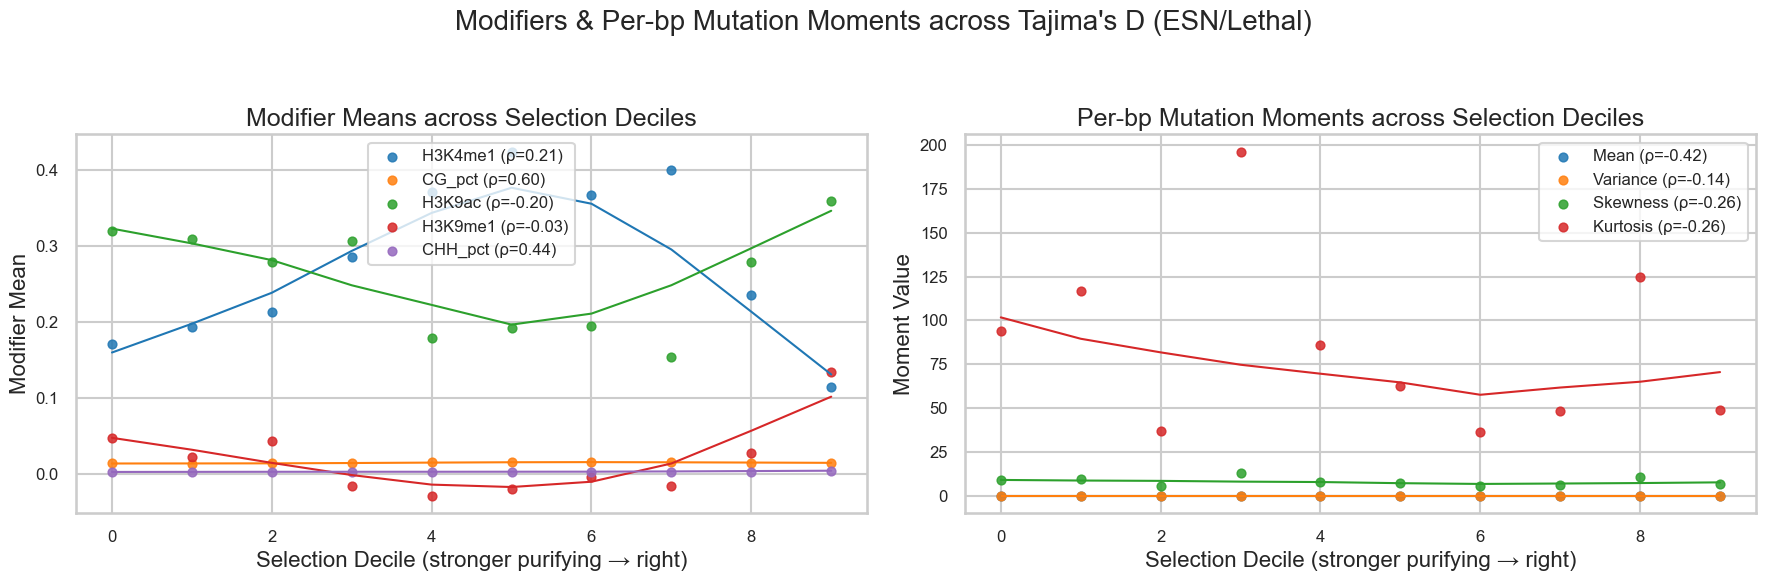


Spearman: selection decile vs modifier means (BH–FDR within family)
  H3K4me1     : rho= 0.212  p= 0.556  q= 0.724
  CG_pct      : rho= 0.600  p= 0.0667  q= 0.333
  H3K9ac      : rho=-0.200  p= 0.58  q= 0.724
  H3K9me1     : rho=-0.030  p= 0.934  q= 0.934
  CHH_pct     : rho= 0.442  p= 0.2  q= 0.501

Spearman: selection decile vs per-bp mutation moments (BH–FDR within family)
  Mean    : rho=-0.418  p= 0.229  q= 0.623
  Variance: rho=-0.139  p= 0.701  q= 0.701
  Skewness: rho=-0.261  p= 0.467  q= 0.623
  Kurtosis: rho=-0.261  p= 0.467  q= 0.623


In [13]:

data_path = Path.home() / "Documents/GitHub/Random_Modifier/data/gene_level_data.csv"
df = pd.read_csv(data_path)

# Restrict to essential/lethal genes 
lethal_mask = df["lethal"].astype(str).str.lower().eq("lethal") if "lethal" in df.columns else False
esn_mask    = df["essentiality"].astype(str).str.upper().eq("ESN") if "essentiality" in df.columns else False
df = df[(lethal_mask) | (esn_mask)].copy()

# Predictors/modifiers to track across selection deciles
modifiers = ["H3K4me1", "CG_pct", "H3K9ac", "H3K9me1", "CHH_pct"]

# Required columns (now using per-bp rate, so need CDS length and Tajima's D)
req_cols = set(modifiers) | {"Mutations", "CDS length", "TajimasD"}
missing_req = [c for c in req_cols if c not in df.columns]
if missing_req:
    raise ValueError(f"Required column(s) missing: {missing_req}")

# Drop rows with NaNs in required columns
df = df.dropna(subset=list(req_cols)).copy()

# Outcome
eps = 1e-9
df["mut_rate_per_bp"] = df["Mutations"] / (df["CDS length"] + eps)



"""
Selection deciles (stronger selection = more negative Tajima's D)
Use qcut on -TajimasD so higher decile = stronger purifying selection
"""
df["Sel_decile"] = pd.qcut(-df["TajimasD"], q=10, labels=False, duplicates="drop").astype("Int64")

# Unique deciles actually formed (avoid duplicating summaries)
valid_deciles = np.sort(df["Sel_decile"].dropna().unique())
n_deciles = len(valid_deciles)
if n_deciles < 3:
    raise ValueError(f"Too few deciles formed from Tajima's D (n={n_deciles}).")

"""
Summarize by selection decile
Aggregate modifier means + moments of per-bp mutation rate within each decile
"""
rows = []
for sel in valid_deciles:
    sub = df[df["Sel_decile"] == sel]
    entry = {"Sel_decile": int(sel)}
    # Mean of modifiers in this decile
    for mod in modifiers:
        entry[f"{mod}_mean"] = float(sub[mod].mean())
    # Moments of per-bp mutation rate in this decile
    vals = sub["mut_rate_per_bp"].dropna().values
    if vals.size == 0:
        entry["Mutations_mean"] = np.nan
        entry["Mutations_var"]  = np.nan
        entry["Mutations_skew"] = np.nan
        entry["Mutations_kurt"] = np.nan
    else:
        entry["Mutations_mean"] = float(np.mean(vals))
        entry["Mutations_var"]  = float(np.var(vals, ddof=1)) if vals.size > 1 else 0.0
        entry["Mutations_skew"] = float(skew(vals, bias=False)) if vals.size >= 3 else np.nan
        entry["Mutations_kurt"] = float(kurtosis(vals, bias=False)) if vals.size >= 4 else np.nan
    rows.append(entry)

summary_df = pd.DataFrame(rows).sort_values("Sel_decile").reset_index(drop=True)


"""
Spearman correlations (selection decile vs. modifier means / moments)
Correlate across *deciles* (n = #unique deciles). Add BH–FDR within families.
"""
mod_corrs = {}
for mod in modifiers:
    rho, p = spearmanr(summary_df["Sel_decile"], summary_df[f"{mod}_mean"], nan_policy="omit")
    mod_corrs[mod] = (rho, p)

mom_cols = {
    "Mean":     "Mutations_mean",
    "Variance": "Mutations_var",
    "Skewness": "Mutations_skew",
    "Kurtosis": "Mutations_kurt"
}
mut_corrs = {}
for name, col in mom_cols.items():
    rho, p = spearmanr(summary_df["Sel_decile"], summary_df[col], nan_policy="omit")
    mut_corrs[name] = (rho, p)

"""
Apply BH–FDR within each family
"""
mod_pvals = [p if p is not None else np.nan for _, p in mod_corrs.values()]
mod_q = multipletests([p for p in mod_pvals if np.isfinite(p)], method="fdr_bh")[1] if np.isfinite(mod_pvals).any() else []
mod_q_map = {}
k = 0
for m, (rho, p) in mod_corrs.items():
    if np.isfinite(p):
        mod_q_map[m] = mod_q[k]; k += 1
    else:
        mod_q_map[m] = np.nan

mut_pvals = [p if p is not None else np.nan for _, p in mut_corrs.values()]
mut_q = multipletests([p for p in mut_pvals if np.isfinite(p)], method="fdr_bh")[1] if np.isfinite(mut_pvals).any() else []
mut_q_map = {}
k = 0
for name, (rho, p) in mut_corrs.items():
    if np.isfinite(p):
        mut_q_map[name] = mut_q[k]; k += 1
    else:
        mut_q_map[name] = np.nan



#  Plotting 
sns.set(style="whitegrid", context="talk")
FIG_DIR  = Path.cwd() / "Figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)
FIG_PATH = FIG_DIR / "af3_tajimas_trends.png"

mod_pal = sns.color_palette("tab10", n_colors=len(modifiers))
mom_pal = sns.color_palette("tab10", n_colors=len(mom_cols))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# 1) Modifier trends across selection deciles
for i, mod in enumerate(modifiers):
    rho, p = mod_corrs[mod]
    q = mod_q_map[mod]
    sig = (np.isfinite(q) and q < 0.05)
    star = "*" if sig else ""
    label = f"{mod} (ρ={rho:.2f}{star})"
    sns.regplot(
        x=summary_df["Sel_decile"],
        y=summary_df[f"{mod}_mean"],
        ax=axes[0],
        lowess=True,
        scatter=True,
        line_kws={"lw": 3 if star else 1.5},
        scatter_kws={"s": 40, "alpha": 0.85},
        color=mod_pal[i],
        label=label,
        ci=None
    )
axes[0].set_title("Modifier Means across Selection Deciles", fontsize=18)
axes[0].set_xlabel("Selection Decile (stronger purifying → right)", fontsize=16)
axes[0].set_ylabel("Modifier Mean", fontsize=16)
axes[0].legend(fontsize=12, frameon=True)
axes[0].tick_params(labelsize=12)

# 2) Mutation-moment trends across selection deciles
for i, (name, col) in enumerate(mom_cols.items()):
    rho, p = mut_corrs[name]
    q = mut_q_map[name]
    sig = (np.isfinite(q) and q < 0.05)
    star = "*" if sig else ""
    label = f"{name} (ρ={rho:.2f}{star})"
    sns.regplot(
        x=summary_df["Sel_decile"],
        y=summary_df[col],
        ax=axes[1],
        lowess=True,
        scatter=True,
        line_kws={"lw": 3 if star else 1.5},
        scatter_kws={"s": 40, "alpha": 0.85},
        color=mom_pal[i],
        label=label,
        ci=None
    )
axes[1].set_title("Per-bp Mutation Moments across Selection Deciles", fontsize=18)
axes[1].set_xlabel("Selection Decile (stronger purifying → right)", fontsize=16)
axes[1].set_ylabel("Moment Value", fontsize=16)
axes[1].legend(fontsize=12, frameon=True)
axes[1].tick_params(labelsize=12)

plt.suptitle("Modifiers & Per-bp Mutation Moments across Tajima's D (ESN/Lethal)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# --- Save & show -----------------------------------------------------------
plt.savefig(FIG_PATH, dpi=300)
plt.show()

# --- Correlation tables (with FDR) -----------------------------------------
print("\nSpearman: selection decile vs modifier means (BH–FDR within family)")
for mod, (rho, p) in mod_corrs.items():
    q = mod_q_map[mod]
    print(f"  {mod:12s}: rho={rho: .3f}  p={p: .3g}  q={q if np.isfinite(q) else np.nan: .3g}")

print("\nSpearman: selection decile vs per-bp mutation moments (BH–FDR within family)")
for name, (rho, p) in mut_corrs.items():
    q = mut_q_map[name]
    print(f"  {name:8s}: rho={rho: .3f}  p={p: .3g}  q={q if np.isfinite(q) else np.nan: .3g}")